In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [20]:
#Data Cleaning

df = pd.read_csv("Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

df.drop(columns=["customerID"], errors="ignore", inplace=True)

print(df.isnull().sum())

Dataset Shape: (7043, 21)
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


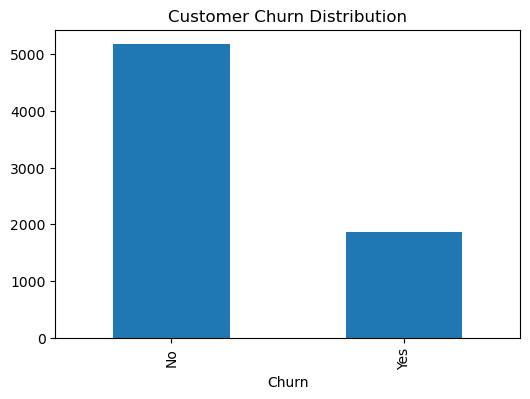

In [21]:
#Churn Rate

churn_rate = (
    df["Churn"]
    .value_counts(normalize=True)
    * 100
)

print(churn_rate)

plt.figure(figsize=(6,4))
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.show()

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


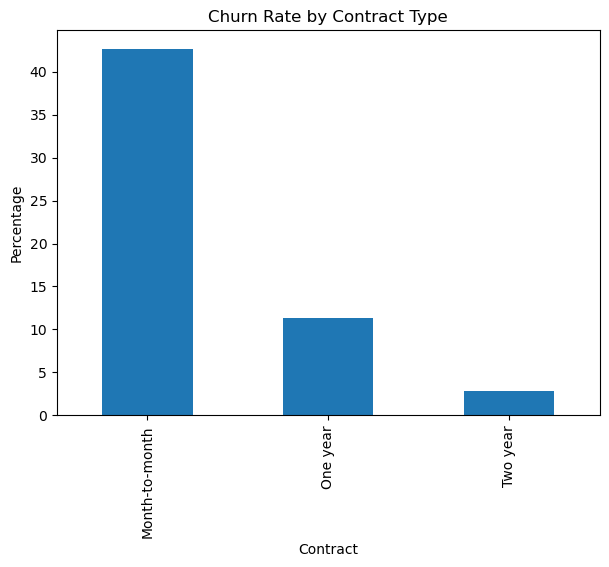

In [22]:
#Contract Type Analysis

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

contract_churn["Yes"].plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Churn Rate by Contract Type")
plt.ylabel("Percentage")
plt.show()

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


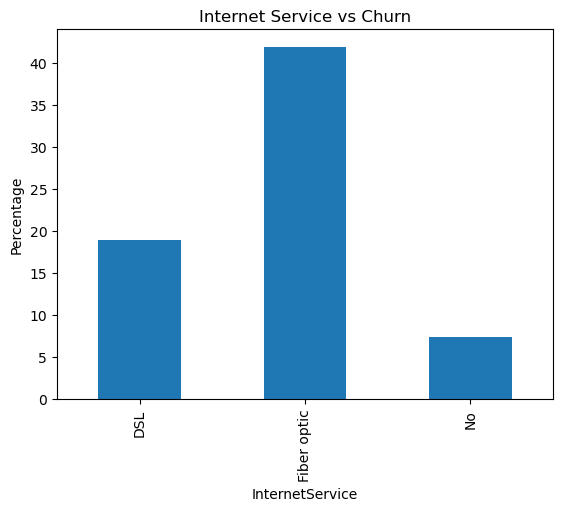

In [23]:
#Internrt Service Analysis

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

internet_churn["Yes"].plot(
    kind="bar"
)

plt.title("Internet Service vs Churn")
plt.ylabel("Percentage")
plt.show()

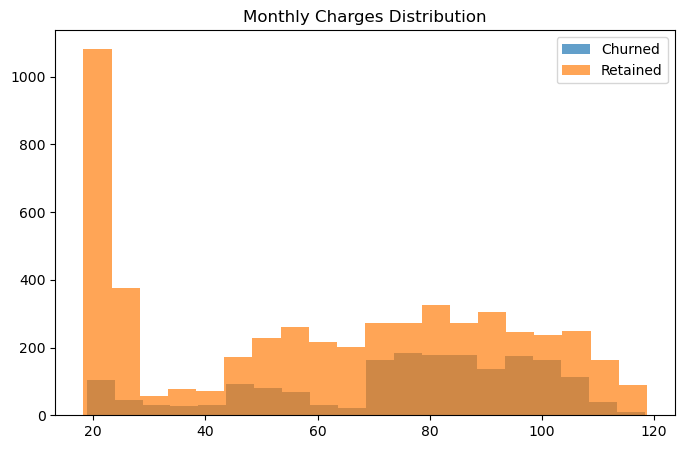

In [24]:
#Monthly Charges Analysis

plt.figure(figsize=(8,5))

plt.hist(
    df[df["Churn"]=="Yes"]["MonthlyCharges"],
    alpha=0.7,
    bins=20,
    label="Churned"
)

plt.hist(
    df[df["Churn"]=="No"]["MonthlyCharges"],
    alpha=0.7,
    bins=20,
    label="Retained"
)

plt.legend()
plt.title("Monthly Charges Distribution")
plt.show()

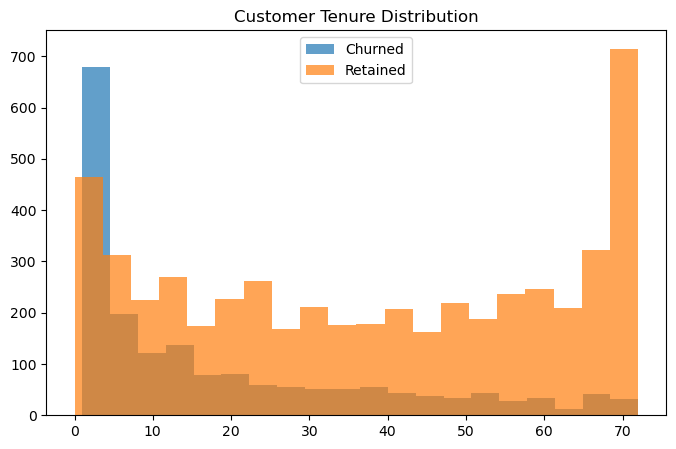

In [25]:
#Tenure Analysis

plt.figure(figsize=(8,5))

plt.hist(
    df[df["Churn"]=="Yes"]["tenure"],
    alpha=0.7,
    bins=20,
    label="Churned"
)

plt.hist(
    df[df["Churn"]=="No"]["tenure"],
    alpha=0.7,
    bins=20,
    label="Retained"
)

plt.legend()
plt.title("Customer Tenure Distribution")
plt.show()

Churn               No        Yes
TenureGroup                      
0-12         52.321839  47.678161
13-24        71.289062  28.710938
25-48        79.611041  20.388959
49-72        90.486824   9.513176


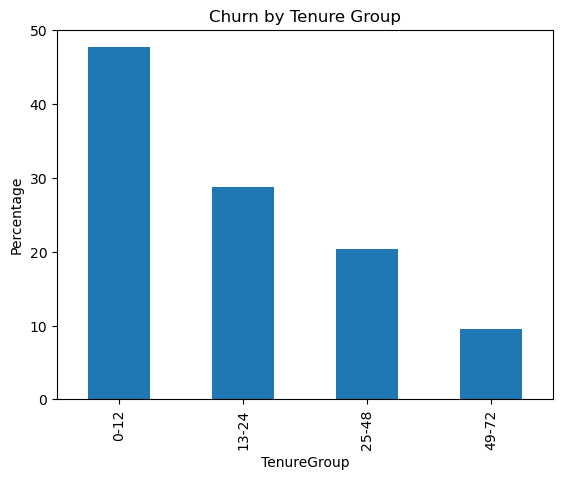

In [26]:
#Customer Segmentation

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12",
        "13-24",
        "25-48",
        "49-72"
    ]
)

segment = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print(segment)

segment["Yes"].plot(kind="bar")

plt.title("Churn by Tenure Group")
plt.ylabel("Percentage")
plt.show()

In [27]:
#Top Churn Drivers

high_risk = df[df["Churn"]=="Yes"]

print("Most Common Contract")
print(high_risk["Contract"].value_counts())

print("\nMost Common Payment Method")
print(high_risk["PaymentMethod"].value_counts())

print("\nMost Common Internet Service")
print(high_risk["InternetService"].value_counts())

Most Common Contract
Contract
Month-to-month    1655
One year           166
Two year            48
Name: count, dtype: int64

Most Common Payment Method
PaymentMethod
Electronic check             1071
Mailed check                  308
Bank transfer (automatic)     258
Credit card (automatic)       232
Name: count, dtype: int64

Most Common Internet Service
InternetService
Fiber optic    1297
DSL             459
No              113
Name: count, dtype: int64


In [28]:
#Feature Encoding

encoded_df = df.copy()

le = LabelEncoder()

for col in encoded_df.columns:
    if encoded_df[col].dtype == "object":
        encoded_df[col] = le.fit_transform(
            encoded_df[col]
        )

In [30]:
#Correalation Analysis

corr_df = encoded_df.drop("TenureGroup", axis=1)

corr = corr_df.corr()

churn_corr = corr["Churn"].sort_values(
    ascending=False
)

print(churn_corr)

Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.199037
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


In [32]:
#Churn Prediction Model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Create a fresh copy
ml_df = encoded_df.copy()

# Remove TenureGroup if it exists
ml_df.drop(columns=["TenureGroup"], errors="ignore", inplace=True)

# Convert any remaining categorical columns
for col in ml_df.columns:
    if ml_df[col].dtype == "object" or str(ml_df[col].dtype) == "category":
        ml_df[col] = LabelEncoder().fit_transform(
            ml_df[col].astype(str)
        )

# Features and Target
X = ml_df.drop("Churn", axis=1)
y = ml_df["Churn"]

# Verify all features are numeric
print("Non-numeric columns:")
print(X.select_dtypes(include=["object", "category"]).columns)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Random Forest Model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluation
print("\nAccuracy Score:")
print(round(accuracy_score(y_test, predictions) * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, predictions))

Non-numeric columns:
Index([], dtype='object')

Accuracy Score:
80.06 %

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409




Top 10 Churn Drivers
             Feature  Importance
4             tenure    0.160796
18      TotalCharges    0.153232
17    MonthlyCharges    0.142026
14          Contract    0.129100
8     OnlineSecurity    0.075669
11       TechSupport    0.059941
7    InternetService    0.044289
16     PaymentMethod    0.043713
9       OnlineBackup    0.028245
15  PaperlessBilling    0.025127


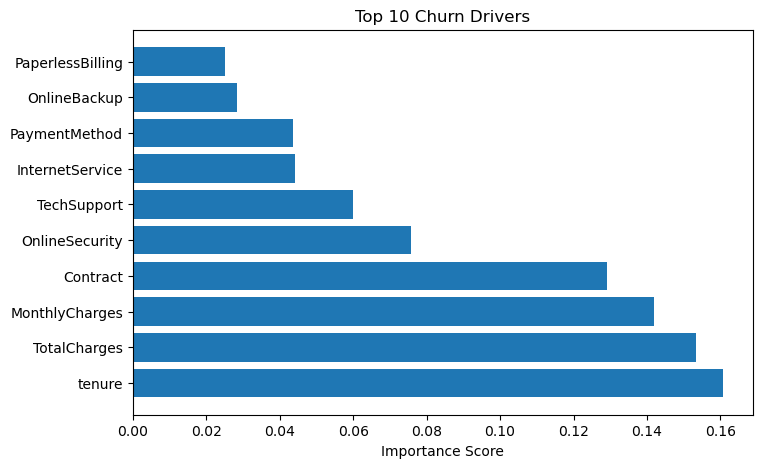

In [35]:
#Featue Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Churn Drivers")
print(importance.head(10))

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"].head(10),
    importance["Importance"].head(10)
)

plt.title("Top 10 Churn Drivers")
plt.xlabel("Importance Score")
plt.show()

In [36]:
print("\nAverage Monthly Charges (Churned Customers):",
      round(df[df["Churn"]=="Yes"]["MonthlyCharges"].mean(),2))

print("Average Monthly Charges (Retained Customers):",
      round(df[df["Churn"]=="No"]["MonthlyCharges"].mean(),2))

print("\nAverage Tenure (Churned Customers):",
      round(df[df["Churn"]=="Yes"]["tenure"].mean(),2))

print("Average Tenure (Retained Customers):",
      round(df[df["Churn"]=="No"]["tenure"].mean(),2))


Average Monthly Charges (Churned Customers): 74.44
Average Monthly Charges (Retained Customers): 61.27

Average Tenure (Churned Customers): 17.98
Average Tenure (Retained Customers): 37.57


In [37]:
#Business Insights

print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

print("\n1. Contract Type Analysis")
print("- Month-to-Month customers exhibit the highest churn rate.")
print("- One-Year and Two-Year contract customers are more likely to stay.")

print("\n2. Customer Tenure Analysis")
print("- Customers with shorter tenure are more likely to churn.")
print("- Long-term customers show stronger loyalty and retention.")

print("\n3. Monthly Charges Analysis")
print("- Customers with higher monthly charges tend to have higher churn rates.")
print("- Pricing may be a significant factor influencing customer decisions.")

print("\n4. Payment Method Analysis")
print("- Customers using Electronic Check show higher churn rates.")
print("- Customers using automatic payment methods demonstrate better retention.")

print("\n5. Service Usage Analysis")
print("- Customers without Online Security and Tech Support are more likely to churn.")
print("- Additional services contribute positively to customer retention.")

print("\n6. Customer Segmentation")
print("- New customers (0-12 months) represent the highest-risk churn segment.")
print("- Retention efforts should focus on early customer engagement.")



BUSINESS INSIGHTS

1. Contract Type Analysis
- Month-to-Month customers exhibit the highest churn rate.
- One-Year and Two-Year contract customers are more likely to stay.

2. Customer Tenure Analysis
- Customers with shorter tenure are more likely to churn.
- Long-term customers show stronger loyalty and retention.

3. Monthly Charges Analysis
- Customers with higher monthly charges tend to have higher churn rates.
- Pricing may be a significant factor influencing customer decisions.

4. Payment Method Analysis
- Customers using Electronic Check show higher churn rates.
- Customers using automatic payment methods demonstrate better retention.

5. Service Usage Analysis
- Customers without Online Security and Tech Support are more likely to churn.
- Additional services contribute positively to customer retention.

6. Customer Segmentation
- New customers (0-12 months) represent the highest-risk churn segment.
- Retention efforts should focus on early customer engagement.
